In [87]:
from getpass import getuser # Libaray to copy things
from pathlib import Path # Object oriented libary to deal with paths
import os
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
from subprocess import run, PIPE
import sys
 
import dask # Distributed data libary
from dask_jobqueue import SLURMCluster # Setting up distributed memories via slurm
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import xarray as xr # Libary to work with labeled n-dimensional data and dask

In [88]:
# Set some user specific variables
scratch_dir = Path('/scratch') / getuser()[0] / getuser() # Define the users scratch dir
# Create a temp directory where the output of distributed cluster will be written to, after this notebook
# is closed the temp directory will be closed
dask_tmp_dir = TemporaryDirectory(dir=scratch_dir, prefix='PostProc')
cluster = SLURMCluster(memory='400GiB',
                       cores=72,
                       project='mh0731',
                       walltime='1:00:00',
                       queue='compute',
                       name='PostProc',
                   #    scheduler_options={'dashboard_address': ':12435'},
                       local_directory=dask_tmp_dir.name,
                       job_extra=[f'-J PostProc', 
                                  f'-D {dask_tmp_dir.name}',
                                  f'--begin=now',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o'
                                 ],
                       interface='ib0')
cluster.scale(jobs=1)
dask_client = Client(cluster)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/slurm.py:49: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-le

In [89]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob

## Load datasets

_ctl_

In [ ]:
import xarray as xr
import numpy as np
import glob
import pandas as pd

# Define the path and file name pattern
data_path_pr_ctl = '/scratch/m/m300948/test_04/pr/'
data_path_ta_ctl = '/scratch/m/m300948/test_04/3d/ta/'
data_path_qa_ctl = '/scratch/m/m300948/test_04/3d/specif_humidity/'

file_pattern = 'ctl_daily_{}_2022{:02d}*.nc'
file_pattern_3d = 'ctl_daily_{}_plev_2022{:02d}*.nc'

# Define latitude and longitude range
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

# Initialize lists to accumulate data
TA_ctl_list = []
QA_ctl_list = []
Precip_ctl_list = []

# Loop over each month
for i in range(1, 13):
    # Use glob to find all files matching the pattern
    pr_files = glob.glob(data_path_pr_ctl + file_pattern.format('pr', i))
    ta_files = glob.glob(data_path_ta_ctl + file_pattern_3d.format('ta', i))
    qa_files = glob.glob(data_path_qa_ctl + file_pattern_3d.format('hus', i))
    
    # Load datasets
    pr_ctl = xr.open_mfdataset(pr_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr'] 
    ta_ctl = xr.open_mfdataset(ta_files, chunks={'time': 1, 'plev':-1, 'lat': -1, 'lon': -1})['ta'] 
    qa_ctl = xr.open_mfdataset(qa_files, chunks={'time': 1, 'plev':-1,'lat': -1, 'lon': -1})['hus']

    # Load the biome mask
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    ABinterp_biome_ctl = AMZ_BD.interp(latitude=ta_ctl.lat, longitude=ta_ctl.lon)
    pr_ctl_mask = pr_ctl.where(ABinterp_biome_ctl == 0, np.nan)
    ta_ctl_mask = ta_ctl.where(ABinterp_biome_ctl == 0, np.nan)
    qa_ctl_mask = qa_ctl.where(ABinterp_biome_ctl == 0, np.nan)
    
    # Select latitude and longitude range
    pr_ctl_sel = pr_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    ta_ctl_sel = ta_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    qa_ctl_sel = qa_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    
    # Mask one hour before the 6n+1-hourly data
    ctl_mask = (pr_ctl_sel.time.dt.hour % 6 == 1) & (pr_ctl_sel*3600 > 50) # 6n+1 에 맞춰서 True false
    pr_ctl_mask_sel = pr_ctl_sel.where(pr_ctl_sel['time'].dt.minute == 0, drop=True).where(ctl_mask) * 3600 # Remove the minute dimension and apply mask
    # Extract only the desired hours (1, 7, 13, 19)
    hours = pr_ctl_mask_sel['time'].dt.hour
    desired_hours = [1, 7, 13, 19]
    pr_ctl_mask_sel_6plus1 = pr_ctl_mask_sel.sel(time=hours.isin(desired_hours))
    
    # Change the time index to 6-hourly, 00:00, 06:00, 12:00, 18:00
    new_time = pd.date_range(start=pr_ctl_mask_sel_6plus1.time.values[0] - pd.Timedelta(hours=1), 
                            periods=len(pr_ctl_mask_sel_6plus1.time), 
                            freq='6H')
    # Assign the new time index to the dataset
    pr_ctl_mask_sel_6plus1['time'] = new_time
    
    # Mask the other datasets
    common_time = pr_ctl_mask_sel_6plus1.time.to_index().intersection(ta_ctl_sel.time.to_index()).intersection(qa_ctl_sel.time.to_index())
    pr_ctl_sel_6plus1_common = pr_ctl_mask_sel_6plus1.sel(time=common_time)
    ta_ctl_sel_common = ta_ctl_sel.sel(time=common_time)
    qa_ctl_sel_common = qa_ctl_sel.sel(time=common_time)
    
    # get datasets 1 hour prior to the intense precipitation
    mask = ~np.isnan(pr_ctl_sel_6plus1_common)
    ta_def_sel_common_mask = ta_ctl_sel_common.where(mask)
    qa_ctl_sel_common_mask = qa_ctl_sel_common.where(mask)

ta_ctl_all = ta_def_sel_common_mask
qa_ctl_all = qa_ctl_sel_common_mask

_def_

In [91]:
import xarray as xr
import numpy as np
import glob
import pandas as pd

# Define the path and file name pattern
data_path_pr_def = '/scratch/m/m300948/def_100/pr/'
data_path_ta_def = '/scratch/m/m300948/def_100/3d/ta/'
data_path_qa_def = '/scratch/m/m300948/def_100/3d/specif_humidity/'

file_pattern = 'def_daily_{}_2022{:02d}*.nc'
file_pattern_3d = 'def_daily_{}_plev_2022{:02d}*.nc'

# Define latitude and longitude range
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

# Initialize lists to accumulate data
TA_def_list = []
QA_def_list = []
Precip_def_list = []

# Loop over each month
for i in range(1, 13):
    # Use glob to find all files matching the pattern
    pr_files = glob.glob(data_path_pr_def + file_pattern.format('pr', i))
    ta_files = glob.glob(data_path_ta_def + file_pattern_3d.format('ta', i))
    qa_files = glob.glob(data_path_qa_def + file_pattern_3d.format('hus', i))
    
    # Load datasets
    pr_def = xr.open_mfdataset(pr_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr'] 
    ta_def = xr.open_mfdataset(ta_files, chunks={'time': 1, 'plev':-1, 'lat': -1, 'lon': -1})['ta'] 
    qa_def = xr.open_mfdataset(qa_files, chunks={'time': 1, 'plev':-1, 'lat': -1, 'lon': -1})['hus']

    # Load the biome mask
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    ABinterp_biome_def = AMZ_BD.interp(latitude=ta_def.lat, longitude=ta_def.lon)
    pr_def_mask = pr_def.where(ABinterp_biome_def == 0, np.nan)
    ta_def_mask = ta_def.where(ABinterp_biome_def == 0, np.nan)
    qa_def_mask = qa_def.where(ABinterp_biome_def == 0, np.nan)
    
    # Select latitude and longitude range
    pr_def_sel = pr_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    ta_def_sel = ta_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    qa_def_sel = qa_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    
    # Mask one hour before the 6n+1-hourly data
    def_mask = (pr_def_sel.time.dt.hour % 6 == 1) & (pr_def_sel*3600 > 50) # 6n+1 에 맞춰서 True false
    pr_def_mask_sel = pr_def_sel.where(pr_def_sel['time'].dt.minute == 0, drop=True).where(def_mask) * 3600 # Remove the minute dimension and apply mask
    # Extract only the desired hours (1, 7, 13, 19)
    hours = pr_def_mask_sel['time'].dt.hour
    desired_hours = [1, 7, 13, 19]
    pr_def_mask_sel_6plus1 = pr_def_mask_sel.sel(time=hours.isin(desired_hours))
    
    # Change the time index to 6-hourly, 00:00, 06:00, 12:00, 18:00
    new_time = pd.date_range(start=pr_def_mask_sel_6plus1.time.values[0] - pd.Timedelta(hours=1), 
                            periods=len(pr_def_mask_sel_6plus1.time), 
                            freq='6H')
    # Assign the new time index to the dataset
    pr_def_mask_sel_6plus1['time'] = new_time
    
    # Mask the other datasets
    common_time = pr_def_mask_sel_6plus1.time.to_index().intersection(ta_def_sel.time.to_index()).intersection(qa_def_sel.time.to_index())
    pr_def_sel_6plus1_common = pr_def_mask_sel_6plus1.sel(time=common_time)
    ta_def_sel_common = ta_def_sel.sel(time=common_time)
    qa_def_sel_common = qa_def_sel.sel(time=common_time)
    
    # get datasets 1 hour prior to the intense precipitation
    mask = ~np.isnan(pr_def_sel_6plus1_common)
    ta_def_sel_common_mask = ta_def_sel_common.where(mask)
    qa_def_sel_common_mask = qa_def_sel_common.where(mask)

ta_def_all = ta_def_sel_common_mask
qa_def_all = qa_def_sel_common_mask

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/tmp/ip

## Find the qa in the range between 0.017 to 0.018

In [39]:
# select based on qa range
mask = (qa_ctl_all.sel(plev=100000) > 0.0175) & (qa_ctl_all.sel(plev=100000) <= 0.018) # time, lat, lon
#qsfc_ctl_range = qa_ctl_all.where((qa_ctl_all.sel(plev=100000) > 0.017) & (qa_ctl_all.sel(plev=100000) <= 0.018)) # time, lat, lon
qa_ctl_applied = qa_ctl_all.where(mask) # time, plev, lat, lon
ta_ctl_applied = ta_ctl_all.where(mask) # time, plev, lat, lon

In [92]:
# select based on qa range
mask = (qa_def_all.sel(plev=100000) > 0.0175) & (qa_def_all.sel(plev=100000) <= 0.018) # time, lat, lon
#qsfc_def_range = qa_def_all.where((qa_def_all.sel(plev=100000) > 0.017) & (qa_def_all.sel(plev=100000) <= 0.018)) # time, lat, lon
qa_def_applied = qa_def_all.where(mask) # time, plev, lat, lon
ta_def_applied = ta_def_all.where(mask) # time, plev, lat, lon

In [40]:
# expand the dimensions into plev and occurs (time, lat, lon) => (plev, occurs)
qa_ctl_applied_expanded = qa_ctl_applied.stack(occurs=('time', 'lat', 'lon')).dropna('occurs')
ta_ctl_applied_expanded = ta_ctl_applied.stack(occurs=('time', 'lat', 'lon')).dropna('occurs')

In [93]:
# expand the dimensions into plev and occurs (time, lat, lon) => (plev, occurs)
qa_def_applied_expanded = qa_def_applied.stack(occurs=('time', 'lat', 'lon')).dropna('occurs')
ta_def_applied_expanded = ta_def_applied.stack(occurs=('time', 'lat', 'lon')).dropna('occurs')

_Reordering data following ascending order_

In [41]:
surface_values = ta_ctl_applied_expanded.sel(plev=100000).values
sorted_indices = np.argsort(surface_values)

In [94]:
surface_values = ta_def_applied_expanded.sel(plev=100000).values
sorted_indices = np.argsort(surface_values)

In [42]:
# Reorder A and B using the sorted indices
ta_ctl_applied_expanded_sorted = ta_ctl_applied_expanded.isel(occurs=sorted_indices)
qa_ctl_applied_expanded_sorted = qa_ctl_applied_expanded.isel(occurs=sorted_indices)

In [95]:
# Reorder A and B using the sorted indices
ta_def_applied_expanded_sorted = ta_def_applied_expanded.isel(occurs=sorted_indices)
qa_def_applied_expanded_sorted = qa_def_applied_expanded.isel(occurs=sorted_indices)

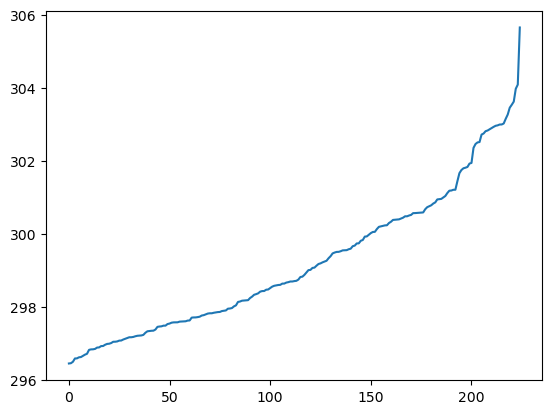

In [96]:
a = ta_def_applied_expanded_sorted.isel(plev=0).values
plt.plot(a)

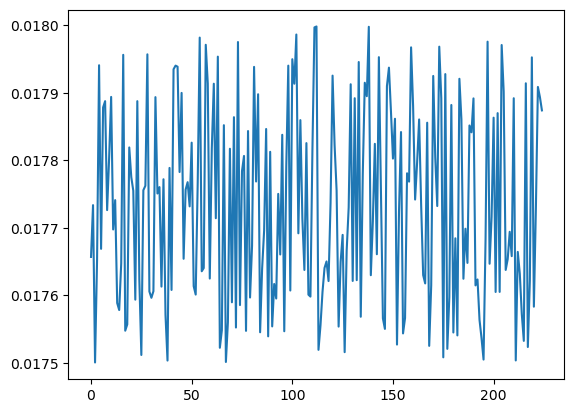

In [97]:
a = qa_def_applied_expanded_sorted.isel(plev=0).values
plt.plot(a)

In [98]:
print(ta_ctl_applied_expanded_sorted.shape) # 250 * 10
print(qa_ctl_applied_expanded_sorted.shape)

(23, 375)
(23, 375)


## Select steps

In [99]:
# 24-26 degree (297-299K) 사이의 온도를 가지는 데이터만 추출
mask = (ta_def_applied_expanded_sorted.isel(plev=0) > 296) & (ta_def_applied_expanded_sorted.isel(plev=0) <= 298)
filtered_ta_def = ta_def_applied_expanded_sorted.where(mask)
filtered_qa_def = qa_def_applied_expanded_sorted.where(mask)
ta_1 = filtered_ta_def.mean(dim='occurs').values
qa_1 = filtered_qa_def.mean(dim='occurs').values

In [100]:
# 26-28 degree
mask = (ta_def_applied_expanded_sorted.isel(plev=0) > 298) & (ta_def_applied_expanded_sorted.isel(plev=0) <= 300)
filtered_ta_def = ta_def_applied_expanded_sorted.where(mask)
filtered_qa_def = qa_def_applied_expanded_sorted.where(mask)
ta_2 = filtered_ta_def.mean(dim='occurs').values
qa_2 = filtered_qa_def.mean(dim='occurs').values

In [101]:
# 28-30 degree
mask = (ta_def_applied_expanded_sorted.isel(plev=0) > 300) & (ta_def_applied_expanded_sorted.isel(plev=0) <= 302)
filtered_ta_def = ta_def_applied_expanded_sorted.where(mask)
filtered_qa_def = qa_def_applied_expanded_sorted.where(mask)
ta_3 = filtered_ta_def.mean(dim='occurs').values
qa_3 = filtered_qa_def.mean(dim='occurs').values

In [102]:
# 30-32 degree
mask = (ta_def_applied_expanded_sorted.isel(plev=0) > 302) & (ta_def_applied_expanded_sorted.isel(plev=0) <= 304)
filtered_ta_def = ta_def_applied_expanded_sorted.where(mask)
filtered_qa_def = qa_def_applied_expanded_sorted.where(mask)
ta_4 = filtered_ta_def.mean(dim='occurs').values
qa_4 = filtered_qa_def.mean(dim='occurs').values

## Calculate CAPE and CIN with a vertical profile

In [103]:
from metpy.calc import relative_humidity_from_specific_humidity
from metpy.calc import cape_cin, dewpoint_from_relative_humidity, parcel_profile
from metpy.units import units

In [104]:
press_hpa = ta_ctl_applied_expanded_sorted.plev.values /100 * units.hPa

In [105]:
xarray_names = ['ta_1','ta_2','ta_3','ta_4']
new_suffix = '_degC'

for name in xarray_names:
    dset_name = name
    xarray_data = globals()[dset_name]
    xarray_data_degC = (xarray_data - 273.15) * units.degC 
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_degC

_Calculate Td_

In [106]:
for num in range(1,5):
    ta_dset_name = 'ta_' + str(num) + '_degC'
    qa_dset_name = 'qa_' + str(num)
    ta_xarray_data = globals()[ta_dset_name]
    qa_xarray_data = globals()[qa_dset_name]
    
    rh = relative_humidity_from_specific_humidity(press_hpa, ta_xarray_data, qa_xarray_data)
    dewpoint = dewpoint_from_relative_humidity(ta_xarray_data, rh)
    globals()['dewpoint_' + str(num)] = dewpoint

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/metpy/calc/thermo.py:1384: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)


_Calculate CAPE_

In [107]:
def cal_cape_cin(pressure_data, temperature_data, dew_temperature_data):
    """
    Function to calculate CAPE and CIN for a single grid point.
    """
    T = temperature_data 
    Td = dew_temperature_data 
    p = pressure_data 
    
    prof = parcel_profile(p, T[0], Td[0]).to('degC')
    cape, cin = cape_cin(p, T, Td, prof)
    return cape.magnitude, cin.magnitude

In [108]:
cape_1, cin_1 = cal_cape_cin(press_hpa, ta_1_degC, dewpoint_1)
cape_2, cin_2 = cal_cape_cin(press_hpa, ta_2_degC, dewpoint_2)
cape_3, cin_3 = cal_cape_cin(press_hpa, ta_3_degC, dewpoint_3)
cape_4, cin_4 = cal_cape_cin(press_hpa, ta_4_degC, dewpoint_4)

In [109]:
print(cape_1, cin_1)
print(cape_2, cin_2)
print(cape_3, cin_3)
print(cape_4, cin_4)

1815.844898306133 -2.131357803925153
2063.319078022443 -21.399669932318695
2517.171032810094 -39.323470456846735
3155.1138542458057 -60.47873981900542


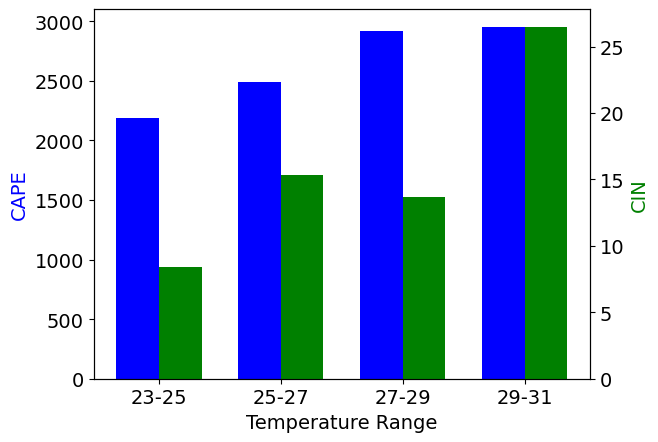

In [110]:
categories = ['23-25', '25-27', '27-29', '29-31']
values1 = [2189.7, 2488.7, 2918.4, 2953.4]
values2 = [8.4, 15.3, 13.7, 26.5]

# Number of categories
n_categories = len(categories)

# Create an array for the x positions of the bars
x = np.arange(n_categories)

# Width of the bars
width = 0.35

# Plotting
fig, ax1 = plt.subplots()

# Plot the first set of bars
bars1 = ax1.bar(x - width/2, values1, width, label='Value Set 1', color='b')
ax1.set_xlabel('Temperature Range', fontsize=14)
ax1.set_ylabel('CAPE', color='b', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=14)
ax1.tick_params(axis='y', labelsize=14)

# Create a second y-axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, values2, width, label='Value Set 2', color='g')
ax2.set_ylabel('CIN', color='g', fontsize=14)
ax2.tick_params(axis='y', labelsize=14)

# Show the plot
plt.show()

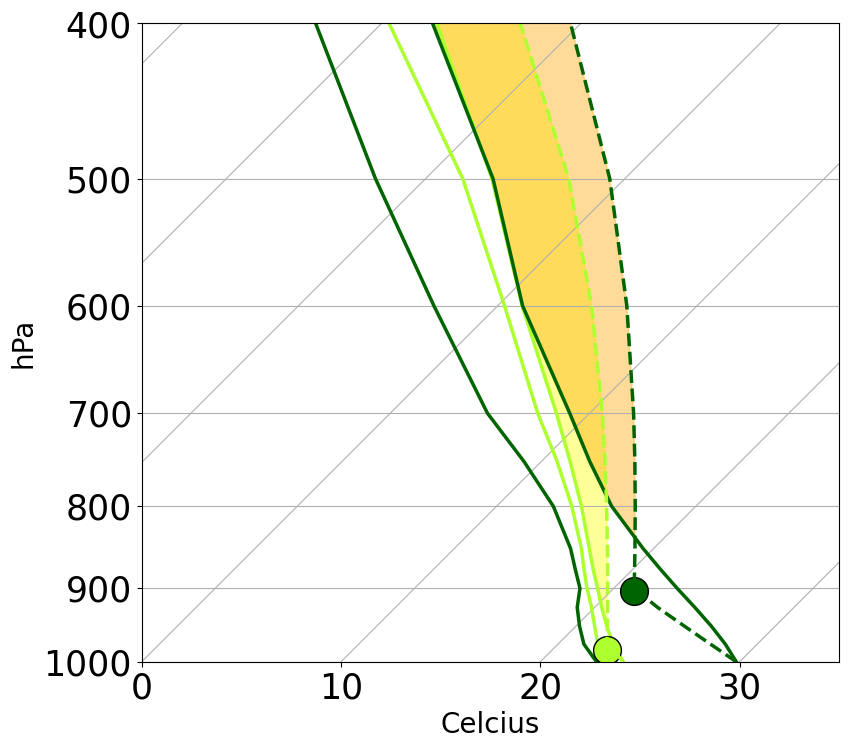

In [111]:
import matplotlib.pyplot as plt
import pandas as pd

import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT

fig = plt.figure(figsize=(9, 9))
skew = SkewT(fig, rotation=45)

# 1
skew.plot(press_hpa, ta_1_degC, 'greenyellow', linewidth=2.5)
skew.plot(press_hpa, dewpoint_1, 'greenyellow', linewidth=2.5)
# 2
#skew.plot(press_hpa, ta_2_degC, 'limegreen', linewidth=2.5)
#skew.plot(press_hpa, dewpoint_2, 'limegreen', linewidth=2.5)
# 3
#skew.plot(press_hpa, ta_3_degC, 'green', linewidth=2.5)
#skew.plot(press_hpa, dewpoint_3, 'green', linewidth=2.5)
# 4
skew.plot(press_hpa, ta_4_degC, 'darkgreen', linewidth=2.5)
skew.plot(press_hpa, dewpoint_4, 'darkgreen', linewidth=2.5)

skew.ax.set_ylim(1000, 200)
skew.ax.set_xlim(-10, 35)

# Set some better labels than the default
skew.ax.set_xlabel(f'Temperature ({ta_1_degC.units:~P})')
skew.ax.set_ylabel(f'Pressure ({press_hpa.units:~P})')

# calculate lcl
lcl_pressure_ctl_1, lcl_temperature_ctl_1 = mpcalc.lcl(press_hpa[0], ta_1_degC[0], dewpoint_1[0])
#lcl_pressure_ctl_2, lcl_temperature_ctl_2 = mpcalc.lcl(press_hpa[0], ta_2_degC[0], dewpoint_2[0])
#lcl_pressure_ctl_3, lcl_temperature_ctl_3 = mpcalc.lcl(press_hpa[0], ta_3_degC[0], dewpoint_3[0])
lcl_pressure_ctl_4, lcl_temperature_ctl_4 = mpcalc.lcl(press_hpa[0], ta_4_degC[0], dewpoint_4[0])

# Plot the LCL as a black dot
skew.plot(lcl_pressure_ctl_1, lcl_temperature_ctl_1, 'ko', markerfacecolor='greenyellow', markersize=20, linewidth=2.5)
#skew.plot(lcl_pressure_ctl_2, lcl_temperature_ctl_2, 'ko', markerfacecolor='limegreen', markersize=20, linewidth=2.5)
#skew.plot(lcl_pressure_ctl_3, lcl_temperature_ctl_3, 'ko', markerfacecolor='green', markersize=20, linewidth=2.5)
skew.plot(lcl_pressure_ctl_4, lcl_temperature_ctl_4, 'ko', markerfacecolor='darkgreen', markersize=20, linewidth=2.5)

# Calculate full parcel profile and add to plot as black line
prof_ctl_1 = mpcalc.parcel_profile(press_hpa, ta_1_degC[0], dewpoint_1[0]).to('degC')
#prof_ctl_2 = mpcalc.parcel_profile(press_hpa, ta_2_degC[0], dewpoint_2[0]).to('degC')
#prof_ctl_3 = mpcalc.parcel_profile(press_hpa, ta_3_degC[0], dewpoint_3[0]).to('degC')
prof_ctl_4 = mpcalc.parcel_profile(press_hpa, ta_4_degC[0], dewpoint_4[0]).to('degC')

# plot profiles
skew.plot(press_hpa, prof_ctl_1, 'greenyellow', ls='--', linewidth=2.5)
#skew.plot(press_hpa, prof_ctl_2, 'limegreen', ls='--', linewidth=2.5)
#skew.plot(press_hpa, prof_ctl_3, 'green', ls='--', linewidth=2.5)
skew.plot(press_hpa, prof_ctl_4, 'darkgreen', ls='--', linewidth=2.5)

# Shade areas of CAPE and CIN
skew.shade_cape(press_hpa[0:21], ta_1_degC[0:21], prof_ctl_1[0:21], color='yellow')
skew.shade_cape(press_hpa[0:21], ta_4_degC[0:21], prof_ctl_4[0:21], color='orange')
#skew.shade_cape(press_hpa[0:21], T_ctl[0:21], prof_ctl[0:21])

#skew.shade_cin(p[0:21], T_def[0:21], prof_def[0:21], Td_def[0:21])
#skew.shade_cape(p[0:21], T_def[0:21], prof_def[0:21])

# An example of a slanted line at constant T -- in this case the 0
# isotherm
#skew.ax.axvline(0, color='c', linestyle='--', linewidth=2)

# Add the relevant special lines
#skew.plot_dry_adiabats()
#skew.plot_moist_adiabats()
#skew.plot_mixing_lines()
plt.ylim(1000, 400)
plt.xlim(0,35)
plt.xlabel('Celcius', fontsize=20)
plt.ylabel('hPa', fontsize=20)
#plt.title('Vertical Distribution of Cloud Water Content Over Time')
plt.xticks(rotation=0, fontsize=25)
plt.yticks(fontsize=25)
# Show the plot
plt.show()

# At 18utc, from original data (2d)

**select the hour**

_Specific time averaged over the whole month_

In [13]:
# Get the time indices where the hour is 0, 6, 12, 18
ta_ctl_dry_18utc = ta_ctl_dry.sel(time=(ta_ctl_dry.time.dt.hour == 18))
ta_def_dry_18utc = ta_def_dry.sel(time=(ta_def_dry.time.dt.hour == 18))

In [14]:
# Get the time indices where the hour is 0, 6, 12, 18
ta_ctl_wet_18utc = ta_ctl_wet.sel(time=(ta_ctl_wet.time.dt.hour == 18))
ta_def_wet_18utc = ta_def_wet.sel(time=(ta_def_wet.time.dt.hour == 18))

In [15]:
qa_ctl_dry_18utc = qa_ctl_dry.sel(time=(qa_ctl_dry.time.dt.hour == 18))
qa_def_dry_18utc = qa_def_dry.sel(time=(qa_def_dry.time.dt.hour == 18))

In [16]:
qa_ctl_wet_18utc = qa_ctl_wet.sel(time=(qa_ctl_wet.time.dt.hour == 18))
qa_def_wet_18utc = qa_def_wet.sel(time=(qa_def_wet.time.dt.hour == 18))

_Specific time on one day_

In [14]:
date = '2022-07-24'

In [15]:
time_indices_ctl = ta_ctl.sel(time=date)['time'].dt.hour == 18
time_indices_def = ta_def.sel(time=date)['time'].dt.hour == 18

In [16]:
# Select the data corresponding to 12pm using the boolean mask
ta_ctl_tstep = ta_ctl.sel(time=date).sel(time=time_indices_ctl)
ta_def_tstep = ta_def.sel(time=date).sel(time=time_indices_def)

In [17]:
qa_ctl_tstep = qa_ctl.sel(time=date).sel(time=time_indices_ctl)
qa_def_tstep = qa_def.sel(time=date).sel(time=time_indices_def)

_at 18UTC in each month_

In [9]:
# hourly, all years into each month
mon_names = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

xarray_names = ['ta_ctl_mask','ta_def_mask','qa_ctl_mask','qa_def_mask']

for name in xarray_names:
    xarray_data = globals()[name]
    for i in np.arange(1,13):
        xarray_data_mon = xarray_data.where(xarray_data.time.dt.month.isin([i]), drop=True)
        new_name = name + '_' + mon_names[i-1] 
        globals()[new_name] = xarray_data_mon

In [10]:
# hourly, all years into each month (e.g., ta_ctl_mask_jan_18utc)
mon_names = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

xarray_names = ['ta_ctl_mask','ta_def_mask','qa_ctl_mask','qa_def_mask']

for name in xarray_names:
    for i in np.arange(1,13):
        dset_name = name + '_' + mon_names[i-1]  
        xarray_data = globals()[dset_name]
        time_indices = xarray_data['time'].dt.hour == 18
        xarray_data_tstep = xarray_data.sel(time=time_indices)

        new_name = name + '_' + mon_names[i-1] + '_18utc'
        globals()[new_name] = xarray_data_tstep

_Averaged_

In [118]:
ta_ctl_dry_18utc_tavg = ta_ctl_dry_18utc.mean(dim='time')
ta_def_dry_18utc_tavg = ta_def_dry_18utc.mean(dim='time')

In [119]:
ta_ctl_wet_18utc_tavg = ta_ctl_wet_18utc.mean(dim='time')
ta_def_wet_18utc_tavg = ta_def_wet_18utc.mean(dim='time')

In [120]:
qa_ctl_dry_18utc_tavg = qa_ctl_dry_18utc.mean(dim='time')
qa_def_dry_18utc_tavg = qa_def_dry_18utc.mean(dim='time')

In [121]:
qa_ctl_wet_18utc_tavg = qa_ctl_wet_18utc.mean(dim='time')
qa_def_wet_18utc_tavg = qa_def_wet_18utc.mean(dim='time')

## 1) Create pressure dataset

In [ ]:
press = ta_ctl.plev.broadcast_like(ta_ctl_dry_18utc_tavg) /100 

## 2) Change the unit (K -> degC)

In [122]:
xarray_names = ['ta_ctl_dry','ta_ctl_wet','ta_def_dry','ta_def_wet']
new_suffix = '_18utc_tavg_degC'

for name in xarray_names:
    dset_name = name + '_18utc_tavg'
    xarray_data = globals()[dset_name]
    
    xarray_data_degC = xarray_data - 273.15
    
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_degC

In [123]:
qa_ctl_wet_18utc_tavg_kgkg = qa_ctl_wet_18utc_tavg
qa_def_wet_18utc_tavg_kgkg = qa_def_wet_18utc_tavg

In [124]:
qa_ctl_dry_18utc_tavg_kgkg = qa_ctl_dry_18utc_tavg
qa_def_dry_18utc_tavg_kgkg = qa_def_dry_18utc_tavg

## 2-2) domain average and make a one dimension array

In [125]:
press_tdavg = press.mean(dim=['lat','lon'])

In [126]:
ta_ctl_dry_18utc_degC_tdavg = ta_ctl_dry_18utc_tavg_degC.mean(dim=['lat','lon']).values
ta_def_dry_18utc_degC_tdavg = ta_def_dry_18utc_tavg_degC.mean(dim=['lat','lon']).values

In [127]:
ta_ctl_wet_18utc_degC_tdavg = ta_ctl_wet_18utc_tavg_degC.mean(dim=['lat','lon']).values
ta_def_wet_18utc_degC_tdavg = ta_def_wet_18utc_tavg_degC.mean(dim=['lat','lon']).values

In [128]:
qa_ctl_dry_18utc_kgkg_tdavg = qa_ctl_dry_18utc_tavg_kgkg.mean(dim=['lat','lon']).values
qa_def_dry_18utc_kgkg_tdavg = qa_def_dry_18utc_tavg_kgkg.mean(dim=['lat','lon']).values

In [129]:
qa_ctl_wet_18utc_kgkg_tdavg = qa_ctl_wet_18utc_tavg_kgkg.mean(dim=['lat','lon']).values
qa_def_wet_18utc_kgkg_tdavg = qa_def_wet_18utc_tavg_kgkg.mean(dim=['lat','lon']).values

## 3) Add units for using metpy functions

In [130]:
from metpy.units import units
press_hpa = press_tdavg * units.hPa
ta_ctl_dry_18utc_degC_tdavg = ta_ctl_dry_18utc_degC_tdavg * units.degC
ta_def_dry_18utc_degC_tdavg = ta_def_dry_18utc_degC_tdavg * units.degC
ta_ctl_wet_18utc_degC_tdavg = ta_ctl_wet_18utc_degC_tdavg * units.degC
ta_def_wet_18utc_degC_tdavg = ta_def_wet_18utc_degC_tdavg * units.degC

In [ ]:
from metpy.units import units
press_hpa = press * units.hPa
ta_ctl_degc = ta_ctl_degc * units.degC
ta_def_degc = ta_def_degc * units.degC

## 4) Calculate rh, Td

In [21]:
from metpy.calc import relative_humidity_from_specific_humidity
from metpy.calc import cape_cin, dewpoint_from_relative_humidity, parcel_profile

In [109]:
rh_ctl = relative_humidity_from_specific_humidity(press_hpa, ta_ctl_degc, qa_ctl_kgkg)

In [110]:
rh_def = relative_humidity_from_specific_humidity(press_hpa, ta_def_degc, qa_def_kgkg)

In [111]:
td_ctl = dewpoint_from_relative_humidity(ta_ctl_degc, rh_ctl)

In [112]:
td_def = dewpoint_from_relative_humidity(ta_def_degc, rh_def)

In [131]:
# rh (dry)
rh_ctl_dry = relative_humidity_from_specific_humidity(press_hpa, ta_ctl_dry_18utc_degC_tdavg, qa_ctl_dry_18utc_kgkg_tdavg)
rh_def_dry = relative_humidity_from_specific_humidity(press_hpa, ta_def_dry_18utc_degC_tdavg, qa_def_dry_18utc_kgkg_tdavg)
# rh (wet)
rh_ctl_wet = relative_humidity_from_specific_humidity(press_hpa, ta_ctl_wet_18utc_degC_tdavg, qa_ctl_wet_18utc_kgkg_tdavg)
rh_def_wet = relative_humidity_from_specific_humidity(press_hpa, ta_def_wet_18utc_degC_tdavg, qa_def_wet_18utc_kgkg_tdavg)
# td (dry)
td_ctl_dry = dewpoint_from_relative_humidity(ta_ctl_dry_18utc_degC_tdavg, rh_ctl_dry)
td_def_dry = dewpoint_from_relative_humidity(ta_def_dry_18utc_degC_tdavg, rh_def_dry)
# td (wet)
td_ctl_wet = dewpoint_from_relative_humidity(ta_ctl_wet_18utc_degC_tdavg, rh_ctl_wet)
td_def_wet = dewpoint_from_relative_humidity(ta_def_wet_18utc_degC_tdavg, rh_def_wet)

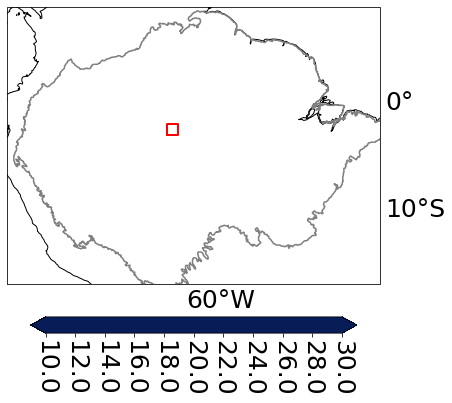

In [191]:
plot_cape(td_ctl.isel(time=0).sel(plev=100000), 30, 10, 11, 'YlGnBu', -80, -45, -17, 9, lat_start, lat_end, lon_start, lon_end)

## 5) Check the interested field

_check the interested field in the order of lon/lat_

In [ ]:
# Specify the latitude and longitude values you're interested in (SW: (-20,-80), NE: (8,-40))
target_lat = 6
target_lon = -63

# Find the index of the nearest latitude and longitude values in the dataset
lat_index = np.abs(ta_ctl_test.lat - target_lat).argmin()
lon_index = np.abs(ta_ctl_test.lon - target_lon).argmin()

# Print the index of the nearest latitude and longitude values
print("Index of latitude corresponding:", lat_index)
print("Index of longitude corresponding:", lon_index)

_check the interested field on the map_

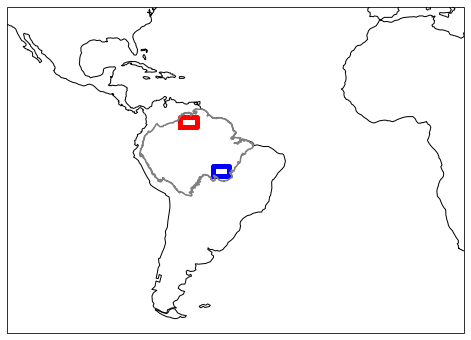

In [127]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Assuming your xarray ta_ctl.isel(time=0).sel(plev=100000)set is named 'ta_ctl.isel(time=0).sel(plev=100000)' and contains latitude and longitude coordinates

# Define the latitude and longitude indices for the rectangular box
# DRY
lat_start_dry = 630
lat_end_dry = 660
lon_start_dry = 530
lon_end_dry = 580
#WET
lat_start_wet = 480
lat_end_wet = 510
lon_start_wet = 630
lon_end_wet = 680

# Amazon basin
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES
    
# Plot the map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

# Plot the rectangular box on top of the map
ax.set_extent([ta_ctl.isel(time=0).sel(plev=100000).lon.min(), ta_ctl.isel(time=0).sel(plev=100000).lon.max(), 
               ta_ctl.isel(time=0).sel(plev=100000).lat.min(), ta_ctl.isel(time=0).sel(plev=100000).lat.max()], crs=ccrs.PlateCarree())

# Plot the smaller box indicating the field of interest (DRY)
ax.plot([ta_ctl.lon[lon_start_dry], ta_ctl.lon[lon_end_dry], ta_ctl.lon[lon_end_dry], ta_ctl.lon[lon_start_dry], ta_ctl.lon[lon_start_dry]], 
        [ta_ctl.lat[lat_start_dry], ta_ctl.lat[lat_start_dry], ta_ctl.lat[lat_end_dry], ta_ctl.lat[lat_end_dry], ta_ctl.lat[lat_start_dry]], 
        color='red', linewidth=5, transform=ccrs.PlateCarree(),zorder=2)
# Plot the smaller box indicating the field of interest (WET)
ax.plot([ta_ctl.lon[lon_start_wet], ta_ctl.lon[lon_end_wet], ta_ctl.lon[lon_end_wet], ta_ctl.lon[lon_start_wet], ta_ctl.lon[lon_start_wet]], 
        [ta_ctl.lat[lat_start_wet], ta_ctl.lat[lat_start_wet], ta_ctl.lat[lat_end_wet], ta_ctl.lat[lat_end_wet], ta_ctl.lat[lat_start_wet]], 
        color='blue', linewidth=5, transform=ccrs.PlateCarree())

# plot amazon basin
kw = {'levels':[-1], 'colors':['gray'], 'linestyles':['solid']}
plot_bd = AMZ_BD.plot.contour( 
                      ax=ax,
                      transform=ccrs.PlateCarree(),
                      **kw
                     )

plt.show()

### Define the domain

In [28]:
# Whole Amazon basin
lat_start = -18
lat_end = 9
lon_start = -80
lon_end = -45

In [148]:
# one point in the Amazon
lat_start = -3
lat_end = -2
lon_start = -65
lon_end = -64

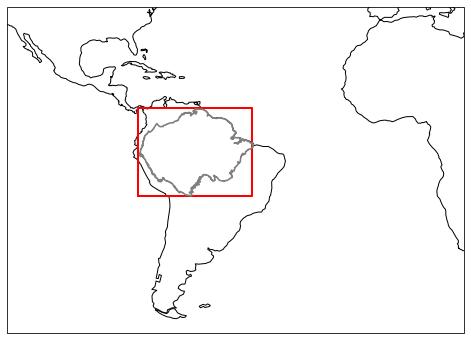

In [402]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Assuming your xarray ta_ctl.isel(time=0).sel(plev=100000)set is named 'ta_ctl.isel(time=0).sel(plev=100000)' and contains latitude and longitude coordinates
# Amazon basin
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES

# Plot the map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

# Plot the rectangular box on top of the map
ax.set_extent([ta_ctl.sel(plev=100000).lon.min(), ta_ctl.sel(plev=100000).lon.max(), 
               ta_ctl.sel(plev=100000).lat.min(), ta_ctl.sel(plev=100000).lat.max()], crs=ccrs.PlateCarree())

# Plot the smaller box indicating the field of interest (DRY)
ax.plot([lon_start, lon_end, lon_end, lon_start, lon_start], 
        [lat_start, lat_start, lat_end, lat_end, lat_start], 
        color='red', linewidth=2, transform=ccrs.PlateCarree(),zorder=2)

# plot amazon basin
kw = {'levels':[-1], 'colors':['gray'], 'linestyles':['solid']}
plot_bd = AMZ_BD.plot.contour( 
                      ax=ax,
                      transform=ccrs.PlateCarree(),
                      **kw
                     )

plt.show()

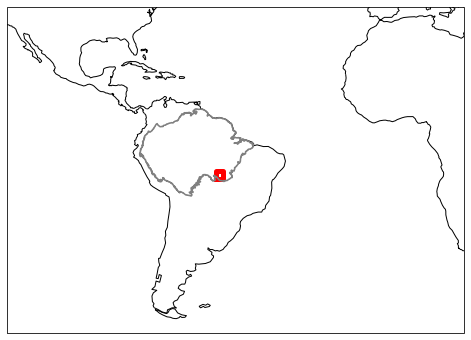

In [132]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Assuming your xarray ta_ctl.isel(time=0).sel(plev=100000)set is named 'ta_ctl.isel(time=0).sel(plev=100000)' and contains latitude and longitude coordinates

# Define the latitude and longitude indices for the rectangular box
lat_start = -12.75
lat_end = -10.25
lon_start = -56
lon_end = -54


# Amazon basin
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES
    
# Plot the map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

# Plot the rectangular box on top of the map
ax.set_extent([ta_ctl.sel(plev=100000).lon.min(), ta_ctl.sel(plev=100000).lon.max(), 
               ta_ctl.sel(plev=100000).lat.min(), ta_ctl.sel(plev=100000).lat.max()], crs=ccrs.PlateCarree())

# Plot the smaller box indicating the field of interest (DRY)
ax.plot([lon_start, lon_end, lon_end, lon_start, lon_start], 
        [lat_start, lat_start, lat_end, lat_end, lat_start], 
        color='red', linewidth=5, transform=ccrs.PlateCarree(),zorder=2)

# plot amazon basin
kw = {'levels':[-1], 'colors':['gray'], 'linestyles':['solid']}
plot_bd = AMZ_BD.plot.contour( 
                      ax=ax,
                      transform=ccrs.PlateCarree(),
                      **kw
                     )

plt.show()

## 6) Calculate CAPE

_select the area: (30, 50) takes 40s, (100, 40) takes 1min 20s, full amazon domain: 40min_

In [113]:
# jas
lat_start = 5.25
lat_end = 6.75
lon_start = -66
lon_end = -64

In [26]:
# djf
lat_start = -12.75
lat_end = -10.25
lon_start = -56
lon_end = -52

In [114]:
press_hpa_sel = press_hpa.sel(lat=slice(lat_start,lat_end), lon=slice(lon_start,lon_end))

In [115]:
ta_ctl_degc_sel = ta_ctl_degc.sel(lat=slice(lat_start,lat_end), lon=slice(lon_start,lon_end))
ta_def_degc_sel = ta_def_degc.sel(lat=slice(lat_start,lat_end), lon=slice(lon_start,lon_end))
td_ctl_degc_sel = td_ctl.sel(lat=slice(lat_start,lat_end), lon=slice(lon_start,lon_end))
td_def_degc_sel = td_def.sel(lat=slice(lat_start,lat_end), lon=slice(lon_start,lon_end))

# Calculate CAPE in 2D

In [29]:
import xarray as xr
import numpy as np
from metpy.units import units
from metpy.calc import cape_cin, parcel_profile

def cal_cape_cin(pressure_data, temperature_data, dew_temperature_data):
    """
    Function to calculate CAPE and CIN for a single grid point.
    """
    T = temperature_data * units.degC
    Td = dew_temperature_data * units.degC
    p = pressure_data * units.hPa
    
    prof = parcel_profile(p, T[0], Td[0]).to('degC')
    cape, cin = cape_cin(p, T, Td, prof)
    return cape.magnitude, cin.magnitude

In [41]:
# Apply xr.apply_ufunc
cape_cin_ctl_result = xr.apply_ufunc(
    cal_cape_cin,
    press_hpa_sel.load(),
    ta_ctl_degc_sel.load(),
    td_ctl_degc_sel.load(),
    input_core_dims=[['plev'], ['plev'], ['plev']], 
    output_core_dims=[[],[]],
    vectorize=True,  # Vectorize the operation
    dask='parallelized',  # Use parallelized computation if using dask
    output_dtypes=[float, float]
)


/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in log
  return func(*(_execute_task(a, cache) for a in args))


In [30]:
# Apply xr.apply_ufunc
cape_cin_def_result = xr.apply_ufunc(
    cal_cape_cin,
    press_hpa_sel.load(),
    ta_def_degc_sel.load(),
    td_def_degc_sel.load(),
    input_core_dims=[['plev'], ['plev'], ['plev']], 
    output_core_dims=[[],[]],
    vectorize=True,  # Vectorize the operation
    dask='parallelized',  # Use parallelized computation if using dask
    output_dtypes=[float, float]
)


/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in log
  return func(*(_execute_task(a, cache) for a in args))


**Functions: Vertical profile**

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from metpy.units import units

In [120]:
# One point (djf: -11.75, -54.25, jas: lat=5.75, lon=-65.15)
p = press_hpa_sel.sel(lat=5.75, lon=-65.15).values * units.hPa
T_ctl = ta_ctl_degc_sel.sel(lat=5.75, lon=-65.15).values * units.degC
Td_ctl = td_ctl_degc_sel.sel(lat=5.75, lon=-65.15).values * units.degC

/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in log
  return func(*(_execute_task(a, cache) for a in args))


In [121]:
T_def = ta_def_degc_sel.sel(lat=5.75, lon=-65.15).values * units.degC
Td_def = td_def_degc_sel.sel(lat=5.75, lon=-65.15).values * units.degC

/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in log
  return func(*(_execute_task(a, cache) for a in args))


In [82]:
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

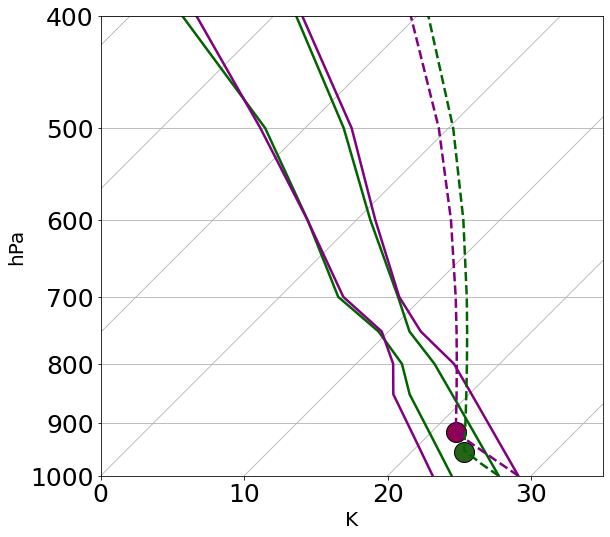

In [122]:
fig = plt.figure(figsize=(9, 9))

skew = SkewT(fig, rotation=45)

# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dictated by the typical meteorological plot.
skew.plot(p, T_ctl, 'darkgreen', linewidth=2.5)
skew.plot(p, Td_ctl, 'darkgreen', linewidth=2.5)
skew.plot(p, T_def, 'purple', linewidth=2.5)
skew.plot(p, Td_def, 'purple', linewidth=2.5)

skew.ax.set_ylim(1000, 200)
skew.ax.set_xlim(-10, 35)

# Set some better labels than the default
skew.ax.set_xlabel(f'Temperature ({T_ctl.units:~P})')
skew.ax.set_ylabel(f'Pressure ({p.units:~P})')

# Calculate LCL height and plot as black dot. Because `p`'s first value is
# ~1000 mb and its last value is ~250 mb, the `0` index is selected for
# `p`, `T`, and `Td` to lift the parcel from the surface. If `p` was inverted,
# i.e. start from low value, 250 mb, to a high value, 1000 mb, the `-1` index
# should be selected.
lcl_pressure_ctl, lcl_temperature_ctl = mpcalc.lcl(p[0], T_ctl[0], Td_ctl[0])
lcl_pressure_def, lcl_temperature_def = mpcalc.lcl(p[0], T_def[0], Td_def[0])
skew.plot(lcl_pressure_ctl, lcl_temperature_ctl, 'ko', markerfacecolor=right, markersize=20, linewidth=2.5)
skew.plot(lcl_pressure_def, lcl_temperature_def, 'ko', markerfacecolor=left, markersize=20, linewidth=2.5)

# Calculate full parcel profile and add to plot as black line
prof_ctl = mpcalc.parcel_profile(p, T_ctl[0], Td_ctl[0]).to('degC')
prof_def = mpcalc.parcel_profile(p, T_def[0], Td_def[0]).to('degC')

skew.plot(p, prof_ctl, 'darkgreen', ls='--', linewidth=2.5)
skew.plot(p, prof_def, 'purple', ls='--',linewidth=2.5)

# Shade areas of CAPE and CIN
#skew.shade_cin(p[0:21], T_ctl[0:21], prof_ctl[0:21], Td_ctl[0:21])
#skew.shade_cape(p[0:21], T_ctl[0:21], prof_ctl[0:21])

#skew.shade_cin(p[0:21], T_def[0:21], prof_def[0:21], Td_def[0:21])
#skew.shade_cape(p[0:21], T_def[0:21], prof_def[0:21])

# An example of a slanted line at constant T -- in this case the 0
# isotherm
#skew.ax.axvline(0, color='c', linestyle='--', linewidth=2)

# Add the relevant special lines
#skew.plot_dry_adiabats()
#skew.plot_moist_adiabats()
#skew.plot_mixing_lines()
plt.ylim(1000, 400)
plt.xlim(0,35)
plt.xlabel('K', fontsize=20)
plt.ylabel('hPa', fontsize=20)
#plt.title('Vertical Distribution of Cloud Water Content Over Time')
plt.xticks(rotation=0, fontsize=25)
plt.yticks(fontsize=25)
# Show the plot
plt.show()

In [49]:
prof = parcel_profile(p, T_ctl[0], Td_ctl[0]).to('degC')
cape, cin = cape_cin(p, T_ctl, Td_ctl, prof)
print(cape, cin)

2251.5699049965756 joule / kilogram -45.08416569768769 joule / kilogram


In [344]:
prof = parcel_profile(p, T_def[0], Td_def[0]).to('degC')
cape, cin = cape_cin(p, T_def, Td_def, prof)
print(cape, cin)

145.8163860438623 joule / kilogram -231.02176759535345 joule / kilogram


_check the dataset type and calculate cape, cin_

In [137]:
T_ctl = ta_ctl_dry_18utc_degC_tdavg
Td_ctl = td_ctl_dry
T_def = ta_def_dry_18utc_degC_tdavg
Td_def = td_def_dry
p = press_hpa.values * units.hPa 
print(type(T_ctl), type(Td_ctl), type(T_def), type(Td_def), type(p))

<class 'pint.util.Quantity'> <class 'pint.util.Quantity'> <class 'pint.util.Quantity'> <class 'pint.util.Quantity'> <class 'pint.util.Quantity'>


In [138]:
prof = parcel_profile(p, T_ctl[0], Td_ctl[0]).to('degC')
cape, cin = cape_cin(p, T_ctl, Td_ctl, prof)
print(cape, cin)

852.3872208539343 joule / kilogram -68.69539825817917 joule / kilogram


In [139]:
prof = parcel_profile(p, T_def[0], Td_def[0]).to('degC')
cape, cin = cape_cin(p, T_def, Td_def, prof)
print(cape, cin)

88.81296377090828 joule / kilogram -259.9605203661471 joule / kilogram


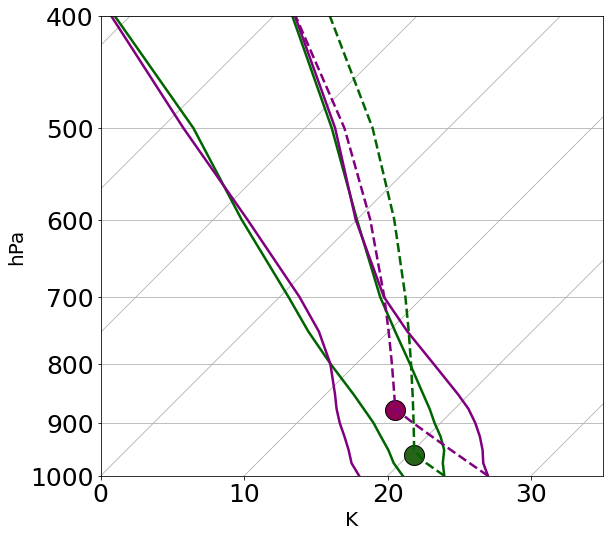

In [140]:
# set T, Td
fig = plt.figure(figsize=(9, 9))

skew = SkewT(fig, rotation=45)

# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dictated by the typical meteorological plot.
skew.plot(p, T_ctl, 'darkgreen', linewidth=2.5)
skew.plot(p, Td_ctl, 'darkgreen', linewidth=2.5)
skew.plot(p, T_def, 'purple', linewidth=2.5)
skew.plot(p, Td_def, 'purple', linewidth=2.5)

skew.ax.set_ylim(1000, 200)
skew.ax.set_xlim(-10, 35)

# Set some better labels than the default
skew.ax.set_xlabel(f'Temperature ({T_ctl.units:~P})')
#skew.ax.set_ylabel(f'Pressure ({p.units:~P})')

# Calculate LCL height and plot as black dot. Because `p`'s first value is
# ~1000 mb and its last value is ~250 mb, the `0` index is selected for
# `p`, `T`, and `Td` to lift the parcel from the surface. If `p` was inverted,
# i.e. start from low value, 250 mb, to a high value, 1000 mb, the `-1` index
# should be selected.
lcl_pressure_ctl, lcl_temperature_ctl = mpcalc.lcl(p[0], T_ctl[0], Td_ctl[0])
lcl_pressure_def, lcl_temperature_def = mpcalc.lcl(p[0], T_def[0], Td_def[0])
skew.plot(lcl_pressure_ctl, lcl_temperature_ctl, 'ko', markerfacecolor=right, markersize=20, linewidth=2.5)
skew.plot(lcl_pressure_def, lcl_temperature_def, 'ko', markerfacecolor=left, markersize=20, linewidth=2.5)

# Calculate full parcel profile and add to plot as black line
prof_ctl = mpcalc.parcel_profile(p, T_ctl[0], Td_ctl[0]).to('degC')
prof_def = mpcalc.parcel_profile(p, T_def[0], Td_def[0]).to('degC')

skew.plot(p, prof_ctl, 'darkgreen', ls='--', linewidth=2.5)
skew.plot(p, prof_def, 'purple', ls='--',linewidth=2.5)

# Shade areas of CAPE and CIN
#skew.shade_cin(p[0:21], T_ctl[0:21], prof_ctl[0:21], Td_ctl[0:21])
#skew.shade_cape(p[0:21], T_ctl[0:21], prof_ctl[0:21])

#skew.shade_cin(p[0:21], T_def[0:21], prof_def[0:21], Td_def[0:21])
#skew.shade_cape(p[0:21], T_def[0:21], prof_def[0:21])

# An example of a slanted line at constant T -- in this case the 0
# isotherm
#skew.ax.axvline(0, color='c', linestyle='--', linewidth=2)

# Add the relevant special lines
#skew.plot_dry_adiabats()
#skew.plot_moist_adiabats()
#skew.plot_mixing_lines()
plt.ylim(1000, 400)
plt.xlim(0,35)
plt.xlabel('K', fontsize=20)
plt.ylabel('hPa', fontsize=20)
#plt.title('Vertical Distribution of Cloud Water Content Over Time')
plt.xticks(rotation=0, fontsize=25)
plt.yticks(fontsize=25)
# Show the plot
plt.show()

**Plotting**

In [32]:
def plot_cape(cape_dset, vmax, vmin, space, cmap, d1_lon_s, d1_lon_e, d1_lat_s, d1_lat_e, d2_lat_s, d2_lat_e, d2_lon_s, d2_lon_e):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
        
    # Plot the map
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()

    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                        xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    # Plot the rectangular box on top of the map
    #ax.set_extent([ta_ctl.isel(time=0).sel(plev=100000).lon.min(), ta_ctl.isel(time=0).sel(plev=100000).lon.max(), 
    #               ta_ctl.isel(time=0).sel(plev=100000).lat.min(), ta_ctl.isel(time=0).sel(plev=100000).lat.max()], crs=ccrs.PlateCarree())
    ax.set_extent([d1_lon_s, d1_lon_e, d1_lat_s, d1_lat_e], crs=ccrs.PlateCarree())
    m = cape_dset.plot(cmap=cmap,add_colorbar=False) #vmin=vmin, vmax=vmax, 
    # Plot the smaller box indicating the field of interest (DRY)
    ax.plot([d2_lon_s, d2_lon_e, d2_lon_e, d2_lon_s, d2_lon_s], 
            [d2_lat_s, d2_lat_s, d2_lat_e, d2_lat_e, d2_lat_s], 
            color='red', linewidth=2, transform=ccrs.PlateCarree(),zorder=2)

    bounds = np.linspace(vmin, vmax, space)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend='both',ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds,rotation=270)

    # plot amazon basin
    kw = {'levels':[-1], 'colors':['gray'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                        ax=ax,
                        transform=ccrs.PlateCarree(),
                        **kw
                        )

    plt.show()

In [31]:
def contourf_extreme(data, cmap, varmin, varmax, space, extend, title):
    fig = plt.figure(figsize=[8,10],facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-80,-45,-17,9])
    ax.coastlines('50m',linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                    xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False
    
    # define lat and lon
    lats = ta_ctl_degc_sel.lat
    lons = ta_ctl_degc_sel.lon

    # Apply the same threshold to both datasets (pr_ctl_mm_hour_mask_q99_counts)
    m = ax.pcolormesh(lons,lats,data,cmap=cmap,vmin=varmin,vmax=varmax,transform=ccrs.PlateCarree())

    #ax.clabel(a, inline=True, fontsize=20)
    #ax.clabel(b, inline=True, fontsize=20)

    kw = {'levels':[-1], 'colors':['lightgrey'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    **kw
                    )
    bounds = np.linspace(varmin, varmax, space)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend,ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds,rotation=270)

    plt.title(title, fontsize='20')
    plt.show()

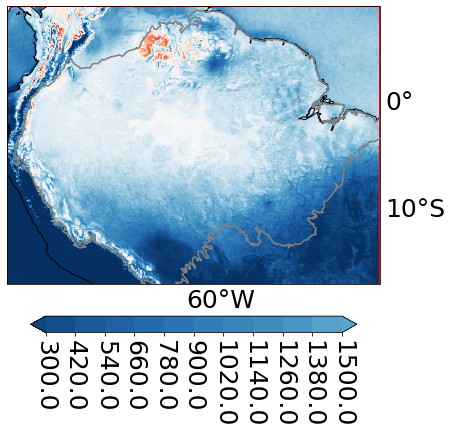

In [52]:
plot_cape(cape_cin_result[0], 1500, 300, 11, 'RdBu_r', -80, -45, -17, 9, lat_start, lat_end, lon_start, lon_end)

In [413]:
diff_cape = cape_cin_def_result[0] - cape_cin_result[0]
diff_cin = -cape_cin_def_result[1] + cape_cin_result[1]

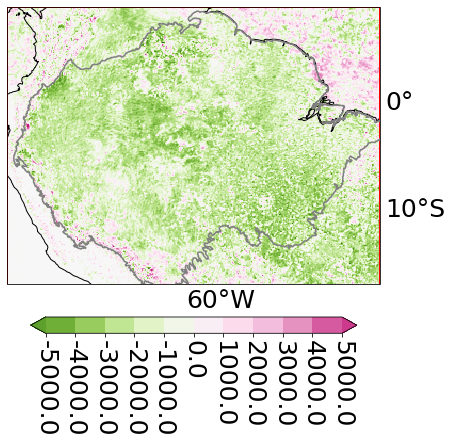

In [414]:
plot_cape(diff_cape, 5000, -5000, 11, 'PiYG_r', -80, -45, -17, 9, lat_start, lat_end, lon_start, lon_end)

# Graph of wind, CAPE, pr

In [241]:
pr_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/pr/ctl_daily_pr_202208*',parallel=True)['pr']*3600*24
pr_def = xr.open_mfdataset('/scratch/m/m300948/def_100/pr/def_daily_pr_202208*',parallel=True)['pr']*3600*24

In [242]:
uas_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/surface_wind/ctl_daily_uas_202208*',parallel=True)['uas']
uas_def = xr.open_mfdataset('/scratch/m/m300948/def_100/surface_wind/def_daily_uas_202208*',parallel=True)['uas']

In [243]:
vas_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/surface_wind/ctl_daily_vas_202208*',parallel=True)['vas']
vas_def = xr.open_mfdataset('/scratch/m/m300948/def_100/surface_wind/def_daily_vas_202208*',parallel=True)['vas']

In [249]:
# for dimension
dim_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/3d/wind/ctl_daily_ua_plev_202208*',parallel=True)['ua']

In [244]:
date = '2022-08-09'
lat = '-2.75'
lon = '-64.25'

In [245]:
pr_ctl_point = pr_ctl.sel(lat=lat, lon=lon).sel(time=date)
pr_def_point = pr_def.sel(lat=lat, lon=lon).sel(time=date)

In [246]:
# ua
uas_ctl_point = uas_ctl.sel(lat=lat, lon=lon).sel(time=date)
uas_def_point = uas_def.sel(lat=lat, lon=lon).sel(time=date)
# va
vas_ctl_point = vas_ctl.sel(lat=lat, lon=lon).sel(time=date)
vas_def_point = vas_def.sel(lat=lat, lon=lon).sel(time=date)

In [247]:
wind_ctl_point = np.sqrt(uas_ctl_point**2 + vas_ctl_point**2)
wind_def_point = np.sqrt(uas_def_point**2 + vas_def_point**2)

In [250]:
dim_point = dim_ctl.sel(lat=lat, lon=lon).sel(time=date)

_CAPE and CIN into xarray_

In [283]:
# with time 
prof = parcel_profile(p[0], T_ctl[3][0], Td_ctl[3][0]).to('degC')
cape_ctl, cin_ctl = cape_cin(p[0], T_ctl[3], Td_ctl[3], prof)
print(cape_ctl, cin_ctl)

2208.5702494148745 joule / kilogram -6.066686368804488 joule / kilogram


In [285]:
length = len(dim_point)
cape_ctl_values = [1334.95,1469.47,657.55,2208.57]
cin_ctl_values = [-29.27,-74.61,-75.50,-6.07]

In [286]:
repeated_constants = np.tile(cape_ctl_values, (length // len(cape_ctl_values) + 1))[:length] # Assuming wind_data['wind'] has 3 dimensions
repeated_constants
# Convert the repeated constants array to an xarray DataArray
cape_ctl_xr = xr.DataArray(repeated_constants, dims=dim_point.sel(plev=100000).dims, coords=dim_point.sel(plev=100000).coords)

In [291]:
# with time 
prof = parcel_profile(p[0], T_def[3][0], Td_def[3][0]).to('degC') # surface, 12.15,06:00
cape_def, cin_def = cape_cin(p[0], T_def[3], Td_def[3], prof)
print(cape_def, cin_def)

769.2239844321151 joule / kilogram 0 joule / kilogram


In [292]:
cape_def_values = [91.73,np.nan,93.33,769.22]
cin_def_values = [-212.30,np.nan,-262.03,0]

In [293]:
repeated_constants = np.tile(cape_def_values, (length // len(cape_def_values) + 1))[:length] # Assuming wind_data['wind'] has 3 dimensions
repeated_constants
# Convert the repeated constants array to an xarray DataArray
cape_def_xr = xr.DataArray(repeated_constants, dims=dim_point.sel(plev=100000).dims, coords=dim_point.sel(plev=100000).coords)

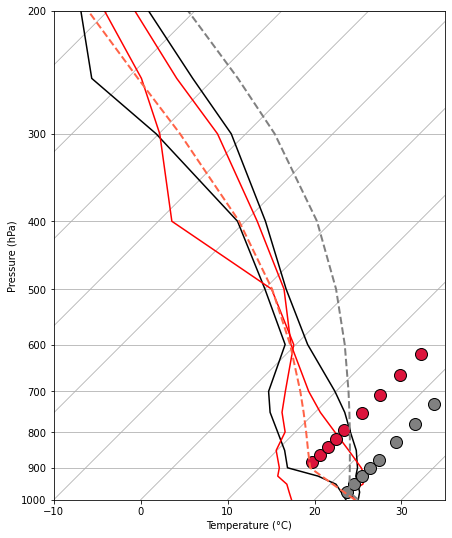

In [73]:
fig = plt.figure(figsize=(9, 9))

skew = SkewT(fig, rotation=45)

# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dictated by the typical meteorological plot.
skew.plot(p[0], T_ctl[0], 'black')
skew.plot(p[0], Td_ctl[0], 'black')
skew.plot(p[0], T_def[1], 'r')
skew.plot(p[0], Td_def[1], 'r')

skew.ax.set_ylim(1000, 200)
skew.ax.set_xlim(-10, 35)

# Set some better labels than the default
skew.ax.set_xlabel(f'Temperature ({T_ctl.units:~P})')
skew.ax.set_ylabel(f'Pressure ({p.units:~P})')

# Calculate LCL height and plot as black dot. Because `p`'s first value is
# ~1000 mb and its last value is ~250 mb, the `0` index is selected for
# `p`, `T`, and `Td` to lift the parcel from the surface. If `p` was inverted,
# i.e. start from low value, 250 mb, to a high value, 1000 mb, the `-1` index
# should be selected.
lcl_pressure_ctl, lcl_temperature_ctl = mpcalc.lcl(p[0], T_ctl[0][0], Td_ctl[1][0])
lcl_pressure_def, lcl_temperature_def = mpcalc.lcl(p[0], T_def[0][0], Td_def[1][0])
skew.plot(lcl_pressure_ctl, lcl_temperature_ctl, 'ko', markerfacecolor='grey', markersize=12)
skew.plot(lcl_pressure_def, lcl_temperature_def, 'ko', markerfacecolor='crimson', markersize=12)

# Calculate full parcel profile and add to plot as black line
prof_ctl = mpcalc.parcel_profile(p[0], T_ctl[0][0], Td_ctl[0][0]).to('degC')
prof_def = mpcalc.parcel_profile(p[0], T_def[1][0], Td_def[1][0]).to('degC')

skew.plot(p[0], prof_ctl, 'grey', ls='--', linewidth=2)
skew.plot(p[0], prof_def, 'tomato', ls='--',linewidth=2)

# Shade areas of CAPE and CIN
#skew.shade_cin(p[0:21], T_ctl[0:21], prof_ctl[0:21], Td_ctl[0:21])
#skew.shade_cape(p[0:21], T_ctl[0:21], prof_ctl[0:21])

#skew.shade_cin(p[0:21], T_def[0:21], prof_def[0:21], Td_def[0:21])
#skew.shade_cape(p[0:21], T_def[0:21], prof_def[0:21])

# An example of a slanted line at constant T -- in this case the 0
# isotherm
#skew.ax.axvline(0, color='c', linestyle='--', linewidth=2)

# Add the relevant special lines
#skew.plot_dry_adiabats()
#skew.plot_moist_adiabats()
#skew.plot_mixing_lines()

# Show the plot
plt.show()

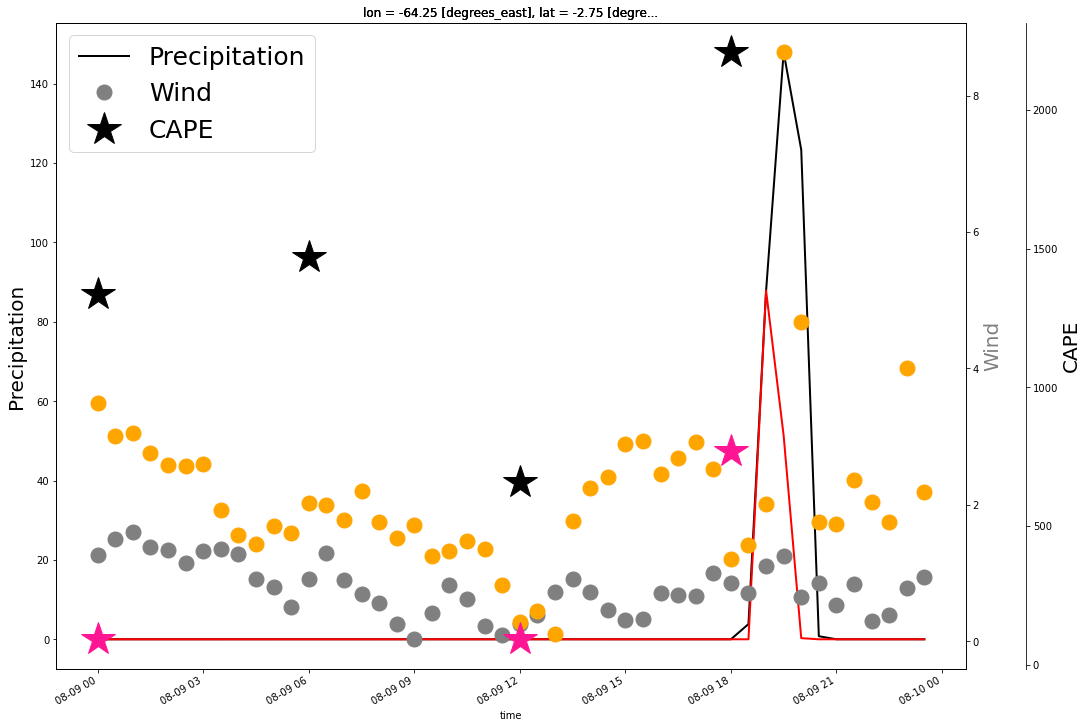

In [294]:
fig, host = plt.subplots(figsize=(15,10), layout='constrained')

ax2 = host.twinx()
ax3 = host.twinx()

p1 = pr_ctl_point.plot(ax=host, label='Precipitation', color='black',linewidth=2)
p2 = pr_def_point.plot(ax=host, label='Precipitation', color='red',linewidth=2)


w1 = wind_ctl_point.plot(ax=ax2,label='Wind', marker='o', linestyle='None', color='grey', markersize=15)
w2 = wind_def_point.plot(ax=ax2, label='Wind', marker='o', linestyle='None', color='orange', markersize=15)

c1 = cape_ctl_xr.plot(ax=ax3, marker='*', linestyle='None', label='CAPE', color='black', markersize=35)
c2 = cape_def_xr.plot(ax=ax3, marker='*', linestyle='None', label='CAPE', color='deeppink', markersize=35)

ax3.spines['right'].set_position(('outward', 60))

host.legend(handles=p1+w1+c1, loc='upper left', fontsize=25)
#host.legend(handles=p2+w2+c2, loc='upper left', fontsize=25)

host.yaxis.label.set_color(p1[0].get_color())
ax2.yaxis.label.set_color(w1[0].get_color())
ax3.yaxis.label.set_color(c1[0].get_color())

# Set labels and title
host.set_ylabel('Precipitation', fontsize=20)
ax2.set_ylabel('Wind', fontsize=20)
ax3.set_ylabel('CAPE', fontsize=20)

plt.show()

# Timeseries of PR, CAPE, Wind

**load precipitation datasets**

In [226]:
pr_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/pr/ctl_daily_pr_2022*',parallel=True)['pr']
pr_def = xr.open_mfdataset('/scratch/m/m300948/def_100/pr/def_daily_pr_2022*',parallel=True)['pr']

_at 18UTC in each month_

In [227]:
# hourly, all years into each month
mon_names = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

xarray_names = ['pr_ctl','pr_def']

for name in xarray_names:
    xarray_data = globals()[name]
    for i in np.arange(1,13):
        xarray_data_mon = xarray_data.where(xarray_data.time.dt.month.isin([i]), drop=True)
        new_name = name + '_' + mon_names[i-1] 
        globals()[new_name] = xarray_data_mon

In [228]:
# hourly, all years into each month (e.g., ta_ctl_mask_jan_18utc)
mon_names = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

xarray_names = ['pr_ctl','pr_def']

for name in xarray_names:
    for i in np.arange(1,13):
        dset_name = name + '_' + mon_names[i-1]  
        xarray_data = globals()[dset_name]
        time_indices = (xarray_data['time'].dt.hour >= 18) & (xarray_data['time'].dt.hour <= 23) # 14-19utc
        xarray_data_tstep = xarray_data.sel(time=time_indices)

        new_name = name + '_' + mon_names[i-1] + '_1823utc'
        globals()[new_name] = xarray_data_tstep

In [234]:
# hourly, all years into each month (e.g., ta_ctl_mask_jan_18utc)
mon_names = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

xarray_names = ['pr_ctl','pr_def']

for name in xarray_names:
    for i in np.arange(1,13):
        dset_name = name + '_' + mon_names[i-1] + '_1823utc' 
        xarray_data = globals()[dset_name]
        xarray_one_day = xarray_data.resample(time='D').mean(dim='time') *3600*24

        new_name = dset_name + '_day'
        globals()[new_name] = xarray_one_day

# a graph wich pr-CAPE, wind-CAPE

In [26]:
from metpy.units import units
from metpy.calc import relative_humidity_from_specific_humidity
from metpy.calc import cape_cin, dewpoint_from_relative_humidity, parcel_profile

In [13]:
# hourly, all years into each month (e.g., ta_ctl_mask_jan_18utc)
mon_names = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

xarray_names = ['_ctl_mask','_def_mask']


for name in xarray_names:
    for i in np.arange(1,13):
        ta_dset_name = 'ta' + name + '_' + mon_names[i-1] + '_18utc' 
        qa_dset_name = 'qa' + name + '_' + mon_names[i-1] + '_18utc' 
        
        ta_xarray_data = globals()[ta_dset_name] - 273.15
        qa_xarray_data = globals()[qa_dset_name]
        
        press_xarray = ta_xarray_data.plev.broadcast_like(ta_xarray_data) /100
        
        ta_xarray_unit = ta_xarray_data * units.degC
        press_xarray_unit = press_xarray * units.hPa
        
        rh_xarray = relative_humidity_from_specific_humidity(press_xarray_unit, ta_xarray_unit, qa_xarray_data)
        td_xarray = dewpoint_from_relative_humidity(ta_xarray_unit, rh_xarray)
        
        pr_new_name = 'press' + name + '_' + mon_names[i-1] + '_18utc'
        rh_new_name = 'rh' + name + '_' + mon_names[i-1] + '_18utc'
        td_new_name = 'td' + name + '_' + mon_names[i-1] + '_18utc'
        ta_new_name = 'ta' + name + '_' + mon_names[i-1] + '_18utc'

        globals()[pr_new_name] = press_xarray_unit
        globals()[rh_new_name] = rh_xarray
        globals()[td_new_name] = td_xarray
        globals()[ta_new_name] = ta_xarray_unit

_average at 18UTC_

In [301]:
# set lat and lon
lat = -5.25
lon = -72.25

T_ctl = ta_ctl_mask_may_18utc.mean(dim='time').sel(lat=lat, lon=lon).values * units.degC
Td_ctl = td_ctl_mask_may_18utc.mean(dim='time').sel(lat=lat, lon=lon).values * units.degC
p = press_ctl_mask_may_18utc.mean(dim='time').sel(lat=lat, lon=lon).values * units.hPa

In [306]:
ta_ctl_mask_may_18utc

<xarray.DataArray 'ta' (time: 0, plev: 22, lat: 300, lon: 400)>
<Quantity(dask.array<mul, shape=(0, 22, 300, 400), dtype=float32, chunksize=(0, 22, 300, 400), chunktype=numpy.ndarray>, 'degree_Celsius')>
Coordinates:
  * time       (time) datetime64[ns] 
  * lon        (lon) float64 -79.95 -79.85 -79.75 ... -40.25 -40.15 -40.05
  * lat        (lat) float64 -19.95 -19.85 -19.75 -19.65 ... 9.65 9.75 9.85 9.95
  * plev       (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
    latitude   (lat) float64 -19.95 -19.85 -19.75 -19.65 ... 9.65 9.75 9.85 9.95
    longitude  (lon) float64 -79.95 -79.85 -79.75 ... -40.25 -40.15 -40.05

In [303]:
T_def = ta_def_mask_may_18utc.mean(dim='time').sel(lat=lat, lon=lon).values * units.degC
Td_def = td_def_mask_may_18utc.mean(dim='time').sel(lat=lat, lon=lon).values * units.degC
p = press_def_mask_may_18utc.mean(dim='time').sel(lat=lat, lon=lon).values * units.hPa

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from metpy.units import units

In [27]:
prof = parcel_profile(p[0:], T_ctl[0], Td_ctl[0]).to('degC')
cape, cin = cape_cin(p[0:], T_ctl[0:], Td_ctl[0:], prof)
print(cape, cin)

NameError: name 'p' is not defined

In [285]:
prof = parcel_profile(p[0:], T_def[0], Td_def[0]).to('degC')
cape, cin = cape_cin(p[0:], T_def[0:], Td_def[0:], prof)
print(cape, cin)

142.04056178302187 joule / kilogram -198.289893095763 joule / kilogram


**Functions: CAPE**

In [295]:
# set lat and lon
lat = -5.25
lon = -72.25

In [296]:
# month = 'dec'
T_ctl = ta_ctl_mask_may_18utc.sel(lat=lat, lon=lon).isel(time=slice(1,32))
Td_ctl = td_ctl_mask_may_18utc.sel(lat=lat, lon=lon).isel(time=slice(1,32))
p = press_ctl_mask_may_18utc.sel(lat=lat, lon=lon).isel(time=slice(1,32))

In [297]:
# month = 'may'
T_def = ta_def_mask_may_18utc.sel(lat=lat, lon=lon).isel(time=slice(1,32))
Td_def = td_def_mask_may_18utc.sel(lat=lat, lon=lon).isel(time=slice(1,32))
p = press_def_mask_may_18utc.sel(lat=lat, lon=lon).isel(time=slice(1,32))

In [262]:
import xarray as xr
import numpy as np
from metpy.units import units
from metpy.calc import cape_cin, parcel_profile

def cal_cape_cin(pressure_data, temperature_data, dew_temperature_data):
    """
    Function to calculate CAPE and CIN for a single grid point.
    """
    T = temperature_data * units.degC
    Td = dew_temperature_data * units.degC
    p = pressure_data * units.hPa
    
    prof = parcel_profile(p[1:], T[1], Td[1]).to('degC')
    cape, cin = cape_cin(p[1:], T[1:], Td[1:], prof)
    return cape.magnitude, cin.magnitude

In [298]:
# Apply xr.apply_ufunc
cape_cin_ctl = xr.apply_ufunc(
    cal_cape_cin,
    p.load(),
    T_ctl.load(),
    Td_ctl.load(),
    input_core_dims=[['plev'], ['plev'], ['plev']], 
    output_core_dims=[[],[]],
    vectorize=True,  # Vectorize the operation
    dask='parallelized',  # Use parallelized computation if using dask
    output_dtypes=[float, float]
)


In [299]:
# Apply xr.apply_ufunc
cape_cin_def = xr.apply_ufunc(
    cal_cape_cin,
    p.load(),
    T_def.load(),
    Td_def.load(),
    input_core_dims=[['plev'], ['plev'], ['plev']], 
    output_core_dims=[[],[]],
    vectorize=True,  # Vectorize the operation
    dask='parallelized',  # Use parallelized computation if using dask
    output_dtypes=[float, float]
)

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

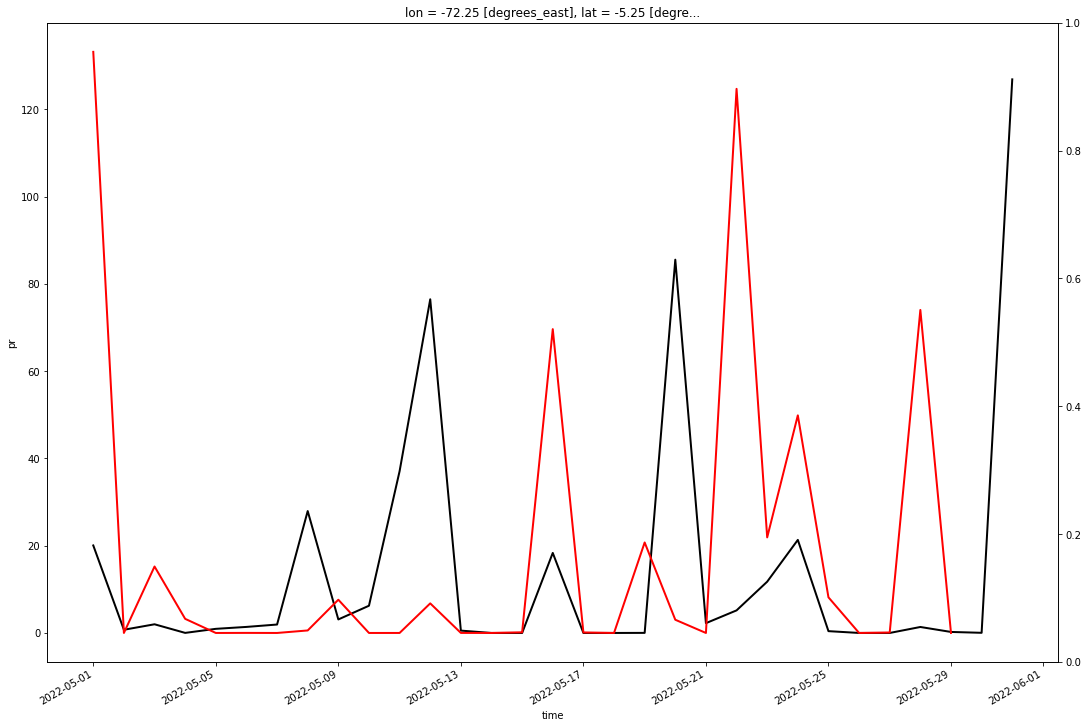

In [300]:
fig, host = plt.subplots(figsize=(15,10), layout='constrained')

ax2 = host.twinx()

# precipitation
p1 = pr_ctl_may_1823utc_day.sel(lat=lat, lon=lon).plot(ax=host, label='Precipitation', color='black',linewidth=2)
p2 = pr_def_may_1823utc_day.sel(lat=lat, lon=lon).plot(ax=host, label='Precipitation', color='red',linewidth=2)

# CAPE
w1 = cape_cin_ctl[0].plot(ax=ax2,label='CAPE', marker='o', linestyle='None', color='grey', markersize=15)
w2 = cape_cin_def[0].plot(ax=ax2, label='CAPE', marker='o', linestyle='None', color='orange', markersize=15)

host.legend(handles=p1+w1, loc='upper left', fontsize=25)

host.yaxis.label.set_color(p1[0].get_color())
ax2.yaxis.label.set_color(w1[0].get_color())

# Set labels and title
host.set_ylabel('Precipitation', fontsize=20)
host.set_xlabel('time', fontsize=20)
ax2.set_ylabel('CAPE', fontsize=20)

# Adjust tick font sizes
host.tick_params(axis='x', which='major', labelsize=20)
host.tick_params(axis='y', which='major', labelsize=20)
ax2.tick_params(axis='y', which='major', labelsize=20)

plt.show()

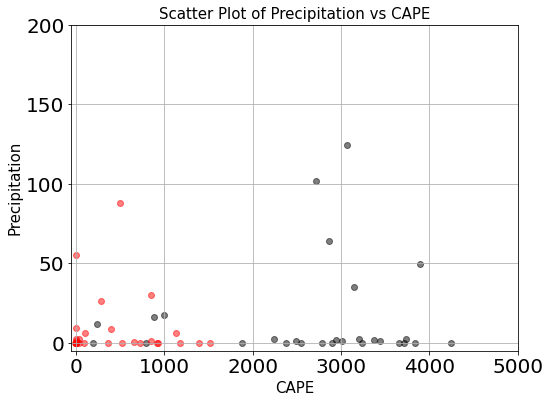

In [294]:
# Convert xarray datasets to pandas DataFrames
pr_df_ctl = pr_ctl_dec_1823utc_day.sel(lat=lat, lon=lon).isel(time=slice(1,32)).to_dataframe()
pr_df_def = pr_def_dec_1823utc_day.sel(lat=lat, lon=lon).isel(time=slice(1,32)).to_dataframe()

cape_df_ctl = pd.DataFrame({'cape': cape_cin_ctl[0]}, index=pr_df_ctl.index)
cape_df_def = pd.DataFrame({'cape': cape_cin_def[0]}, index=pr_df_def.index)

# Merge the DataFrames on the time index
merged_df_ctl = pd.merge(pr_df_ctl, cape_df_ctl, on='time', how='inner')
merged_df_def = pd.merge(pr_df_def, cape_df_def, on='time', how='inner')

# Plot the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(merged_df_ctl['cape'], merged_df_ctl['pr'], alpha=0.5, color='black')
plt.scatter(merged_df_def['cape'], merged_df_def['pr'], alpha=0.5, color='red')
plt.xlabel('CAPE', fontsize=15)
plt.ylabel('Precipitation', fontsize=15)
plt.title('Scatter Plot of Precipitation vs CAPE', fontsize=15)
plt.grid(True)
plt.xlim(-50, 5000)
plt.ylim(-5,200)
# Adjust tick font sizes
plt.tick_params(axis='x', which='major', labelsize=20)
plt.tick_params(axis='y', which='major', labelsize=20)
plt.show()

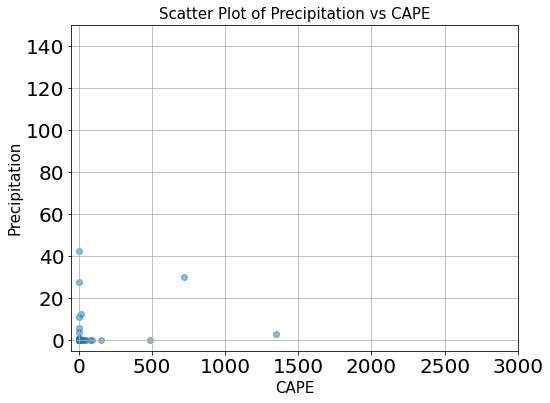

In [121]:
# Convert xarray datasets to pandas DataFrames
pr_df = pr_def_aug_1823utc_day.sel(lat=3.25, lon=-70.25).to_dataframe()
cape_df = pd.DataFrame({'cape': cape_cin_def[0]}, index=pr_df.index)
# Merge the DataFrames on the time index
merged_df = pd.merge(pr_df, cape_df, on='time', how='inner')

# Plot the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(merged_df['cape'], merged_df['pr'], alpha=0.5)
plt.xlabel('CAPE', fontsize=15)
plt.ylabel('Precipitation', fontsize=15)
plt.title('Scatter Plot of Precipitation vs CAPE', fontsize=15)
plt.grid(True)
plt.xlim(-50, 3000)
plt.ylim(-5,150)
# Adjust tick font sizes
plt.tick_params(axis='x', which='major', labelsize=20)
plt.tick_params(axis='y', which='major', labelsize=20)
plt.show()